In [89]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import jit, vmap, grad
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from jax import random
import jax
import time
from tqdm import tqdm

In [90]:
class GaussianKDE(object):
  """
  A Gaussian Kernel Density Estimator.
  """
  def __init__(self, bandwidth):
    self.bandwidth = bandwidth # represents the variance

  def _log_density(self, x, points):
    n_data, d = points.shape
    assert x.shape == (d,)

    # evaluate log normal density centred at points
    logpdfs = vmap(lambda y: multivariate_normal.logpdf(x, y, self.bandwidth**2))(points)
    logpdfs = jnp.array(logpdfs)
    # compute logpdf using logsumexp
    logpdf = jax.scipy.special.logsumexp(logpdfs) - jnp.log(n_data)
    return logpdf

  def log_density(self, X, points):
    logpdfs = vmap(lambda x: self._log_density(x, points))(X)
    return logpdfs

  def sample(self, key, points, n_samples=1):
    subkey1, subkey2 = random.split(key)
    idx = random.choice(subkey1, len(points), shape=(n_samples,), replace=True)
    samples = points[idx] + random.normal(subkey2, shape=(n_samples, points.shape[1])) * self.bandwidth
    return samples



class F_P:
    def __init__(self, log_q0, L):
        self.log_q0 = log_q0
        self.L = L

    def kl_divergence_kde(self, key, X, num_samples=50):
        n, d = X.shape
        kde = GaussianKDE(bandwidth=1/jnp.sqrt(n))
        key, subkey = random.split(key)
        samples = kde.sample(subkey, X, n_samples=num_samples)
        log_qn_eval = kde.log_density(samples, X)
        log_q0_eval = vmap(lambda x: self.log_q0(x))(samples)
        kl_estimate = jnp.mean(log_qn_eval- log_q0_eval)
        return kl_estimate

    def evaluate(self, key, X, num_samples=50):
        KL = self.kl_divergence_kde(key, X, num_samples)
        return self.L(X) + KL

In [91]:
class MeanFieldLangevinDynamics:
    def __init__(self, log_q0, L):
        self.log_q0 = log_q0
        self.S_q0 = jit(vmap(grad(self.log_q0)))
        self.L = L
        self.gradL = jit(grad(lambda X : jax.lax.stop_gradient(len(X)) * self.L(X)))
        self.S_PQ = jit(lambda X: self.S_q0(X) - self.gradL(X))
        

    def run_particles(self, key, eta, T, X0):
        n, d = X0.shape
        device = X0.device
        X = X0.copy()
        particles = [X]

        subkeys = random.split(key, T-1)
        for it in range(T):
            Z = random.normal(subkeys[it], shape=(n, d))
            X = X + eta * self.S_PQ(X) + jnp.sqrt(2 * eta) * Z
            particles.append(X)
        return particles

In [92]:
from jax import grad, random,vmap,tree_util
from jax.flatten_util import ravel_pytree

def init_params(key, input_dim, hidden_dim):
  subkey1, subkey2 = random.split(key)
  params = {
      'W1': random.normal(subkey1, (hidden_dim, input_dim)) * 1.0,
      'b1': jnp.zeros(hidden_dim),
      'W2': random.normal(subkey2, (1, hidden_dim)) * 1.0,
      'b2': jnp.zeros(1),
  }
  return params

@jit
def forward(params, z):
  h = jnp.tanh(jnp.dot(params['W1'], z) + params['b1'])  # hidden layer
  y = jnp.dot(params['W2'], h) + params['b2']             # scalar output
  return y.squeeze()

def forward_(X, z, unravel_fn):
  E = jnp.mean(jit(vmap(lambda x : forward(unravel_fn(x), z)))(X))
  return E

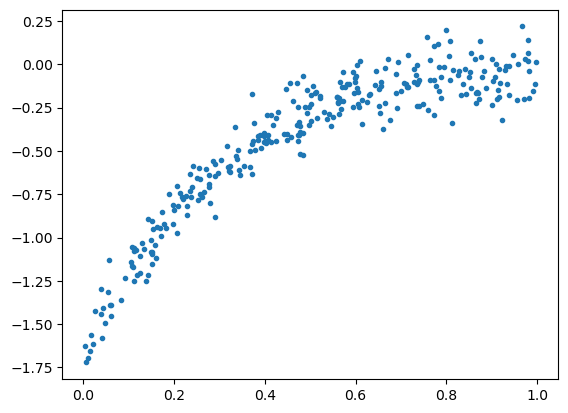

In [93]:
def target_function(z):
  params = jnp.array([2, 0.5, 3, -3])
  return params[2]*jnp.tanh(params[0]*z.squeeze()+params[1]) + params[3]  
  # params = jnp.array([2, -0.5, 3, -3])
  # return params[2]*jnp.tanh(params[0]*z.squeeze()-params[1]) + params[3]
  # return z.squeeze()**2
  # return jnp.sin(2 * jnp.pi * z[:,0])#, 0]) + 0.5 * Z[:, 1]**2 - jnp.exp(-Z[:, 2])

def generate_data(key, s, N=300, noise_std=0.1):
    key_z, key_noise = random.split(key)
    Z = random.uniform(key_z, (N, s),minval = 0,maxval=1.0)  # uniform distribution [-1,1]
    Y_clean = target_function(Z)
    noise = noise_std * random.normal(key_noise, shape=Y_clean.shape)
    Y = Y_clean + noise
    return Z, Y

s = 1 #input dimension
key = random.PRNGKey(1003)
key, subkey = random.split(key)
N = 300
Z, Y = generate_data(subkey, s, N=N, noise_std=0.1) # put more noise
device = jax.devices()[0]
Z, Y = jax.device_put((Z, Y), device)
plt.plot(Z,Y,".")

In [94]:
def log_q0(x, cov=1.):
  return multivariate_normal.logpdf(x, jnp.zeros_like(x), cov)

def L(X, unravel_fn, gamma=100):
    n = len(X)
    Esp_forward = vmap(lambda z: forward_(X, z, unravel_fn))(Z)
    return gamma * jnp.mean((Esp_forward - Y) ** 2) #+ lambd * 1/n * jnp.sum(X ** 2)

# This part is required to obtain unravel_fn
hidden_dim = 1
params = init_params(key, s, hidden_dim)
params = jax.device_put(params, device)
flat_params, unravel_fn = ravel_pytree(params)

# q0cov = 1
# log_q0_ = lambda x: log_q0(x, q0cov)
gamma = 500
L_ = lambda X: L(X, unravel_fn, gamma)
MFLD = MeanFieldLangevinDynamics(log_q0, L_)

In [95]:
class GradientKernel:
    def __init__(self, S_PQ, k):
        self.S_PQ = S_PQ
        self.k = jit(k)
        self.dkx = jit(jacrev(self.k, argnums=0))
        self.dky = jit(jacrev(self.k, argnums=1))
        self.d2k = jit(jacfwd(self.dky, argnums=0))
        self.K = lambda X : vmap(lambda x: vmap(lambda y: self.k(x, y))(X))(X)
        self.dKx = lambda X : vmap(lambda x: vmap(lambda y: self.dkx(x, y))(X))(X)
        self.d2K = lambda X : vmap(lambda x: vmap(lambda y: jnp.trace(self.d2k(x, y)))(X))(X)


    def evaluate(self, X):
        K = self.K(X)
        dK = self.dKx(X)
        d2K = self.d2K(X)
        S_PQ = self.S_PQ(X)
        S_dK = jnp.einsum('ijk, ijk -> ij', dK, (S_PQ[None, :, :]))
        k_pq = d2K + S_dK + S_dK.T + K * jnp.dot(S_PQ, S_PQ.T)
        return k_pq



def kgd(k_pq, X):
  return k_pq.evaluate(X).mean()

def k_imq(x, y, c, b, scale=1.):
  assert b > 0
  return (c**2 + (x-y).dot(x-y)/scale**2)**(-b)


In [96]:
scale = 1
# k = jit(lambda x, y: k_imq(x/scale, y/scale, 1, 0.5) + x.dot(y))
k = jit(lambda x, y: k_imq(x, y, 1, 0.5, scale))
# k = lambda x, y: x.dot(y)
k_pq = GradientKernel(MFLD.S_PQ, k)

In [97]:
T = 10000
num_particles = 100

num_stepsizes = 30
etas = jnp.logspace(-5, -2.8, num_stepsizes)
d = len(flat_params)
device = jax.devices()[0]

n_sim = 1
final_particles = jnp.empty((num_stepsizes, n_sim, num_particles, d))

key, subkey = random.split(key)
X0 = 3*random.normal(subkey, shape=(num_particles, d))
X0 = jax.device_put(X0, device)

for sim in range(n_sim):
  for e, eta in (enumerate(tqdm(etas))):
    key, subkey = random.split(key)
    Xfinal = MFLD.run_particles(subkey, eta, T, X0)[-1]
    final_particles = final_particles.at[e, sim].set(Xfinal)


100%|██████████| 30/30 [01:01<00:00,  2.05s/it]


In [98]:
# lower/upper quantiles
ql = 0.05
qr = 0.95

In [99]:
kgds = [[kgd(k_pq, final_particles[e, sim]) for e in range(num_stepsizes)] for sim in range(n_sim)]
kgds = jnp.array(kgds)
median_kgd = jnp.median(kgds, axis=0)
kgd_ci_low = jnp.quantile(kgds, ql, axis=0)
kgd_ci_high = jnp.quantile(kgds, qr, axis=0)

In [100]:
objectives = [[L_(final_particles[e, sim]) for e in range(num_stepsizes)] for sim in range(n_sim)]
objectives = jnp.array(objectives)
median_obj = jnp.median(objectives, axis=0)
obj_ci_low = jnp.quantile(objectives, ql, axis=0)
obj_ci_high = jnp.quantile(objectives, qr, axis=0)

In [101]:
key, subkey = random.split(key)
entropic_objectives = [[F_P(log_q0, L_).evaluate(subkey, final_particles[e, sim], num_samples=300) for e in range(num_stepsizes)] for sim in range(n_sim)]
entropic_objectives = jnp.array(entropic_objectives)
median_eobj = jnp.median(entropic_objectives, axis=0)
eobj_ci_low = jnp.quantile(entropic_objectives, ql, axis=0)
eobj_ci_high = jnp.quantile(entropic_objectives, qr, axis=0)

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
/var/folders/zl/0c18q_l567xgnm85cwp5t7xm0000gp/T/ipykernel_31016/1466984855.py:5: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title('$\mathcal{L}$')
/var/folders/zl/0c18q_l567xgnm85cwp5t7xm0000gp/T/ipykernel_31016/1466984855.py:12: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_title('$\mathcal{F}_P$')
/var/folders/zl/0c18q_l567xgnm85cwp5t7xm0000gp/T/ipykernel_31016/1466984855.py:14: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('$\mathcal{F}_P$ Value')


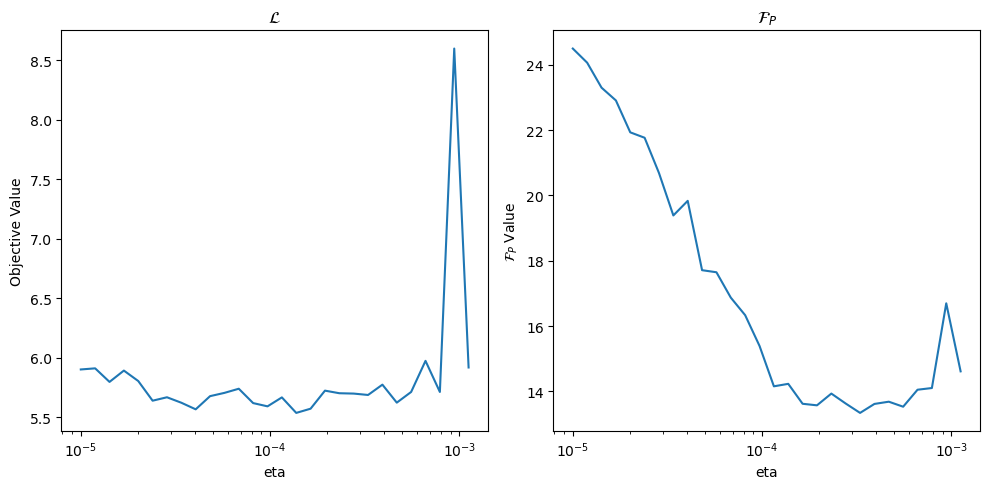

In [122]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

ax1.plot(etas, median_obj)
ax1.fill_between(etas, obj_ci_low, obj_ci_high, alpha=0.2)
ax1.set_title('$\mathcal{L}$')
ax1.set_xlabel('eta')
ax1.set_ylabel('Objective Value')
ax1.set_xscale('log')

ax2.plot(etas, median_eobj)
ax2.fill_between(etas, eobj_ci_low, eobj_ci_high, alpha=0.2)
ax2.set_title('$\mathcal{F}_P$')
ax2.set_xlabel('eta')
ax2.set_ylabel('$\mathcal{F}_P$ Value')
ax2.set_xscale('log')

# ax3.plot(etas, median_kgd)
# ax3.fill_between(etas, kgd_ci_low, kgd_ci_high, alpha=0.2)
# ax3.set_title('KGDs')
# ax3.set_xlabel('eta')
# ax3.set_ylabel('KGD Value')
# ax3.set_xscale('log')
# ax3.set_yscale('log')



plt.tight_layout()
plt.show()

In [103]:
kgds

Array([[8.5513526e-01, 4.9591880e+00, 1.7711293e+00, 1.8396676e+00,
        5.2370563e+00, 7.8299804e+00, 6.1558074e-01, 2.9051802e+00,
        1.6079775e+00, 1.2996854e+00, 2.5403242e+00, 1.3260820e+01,
        1.6407272e+00, 4.3402109e-01, 3.3353618e-01, 1.0239300e+00,
        1.8931226e+00, 5.3090960e-01, 5.6906754e-01, 6.4517012e+00,
        4.6761653e-01, 1.0267379e+00, 7.1739066e-01, 3.9824014e+00,
        4.5950704e+00, 3.6015713e+01, 2.1012744e+03, 2.0518391e+02,
                  nan,           nan]], dtype=float32)

In [104]:
final_particles.shape

(30, 1, 100, 4)

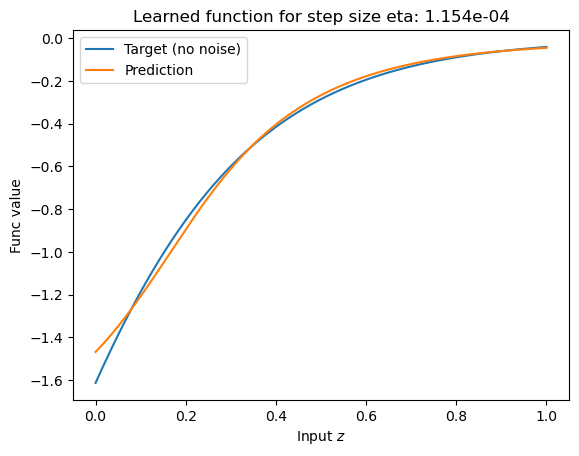

In [105]:
ntestpoints = 400
Ztest = jnp.linspace(0, 1, ntestpoints).reshape(-1, 1)
target_values = target_function(Ztest)
i_eta = jnp.nanargmin(kgds) # -4 # step size's index
# predictions =  vmap(lambda i: vmap(lambda z: forward_(final_particles[i_eta, i], z, unravel_fn))(Ztest))(jnp.arange(n_sim)).mean(axis=0)
predictions =  vmap(lambda z: forward_(final_particles[i_eta, 0], z, unravel_fn))(Ztest)

plt.plot(Ztest, target_values, label='Target (no noise)')
plt.plot(Ztest, predictions, label='Prediction')
plt.xlabel('Input $z$')
plt.ylabel('Func value')
plt.title('Learned function for step size eta: {0:.3e}'.format(etas[i_eta]))
plt.legend()
plt.show()

In [106]:
particles_opt = MFLD.run_particles(subkey, etas[i_eta], T, X0)
F = particles_opt[-1]

(100, 4)


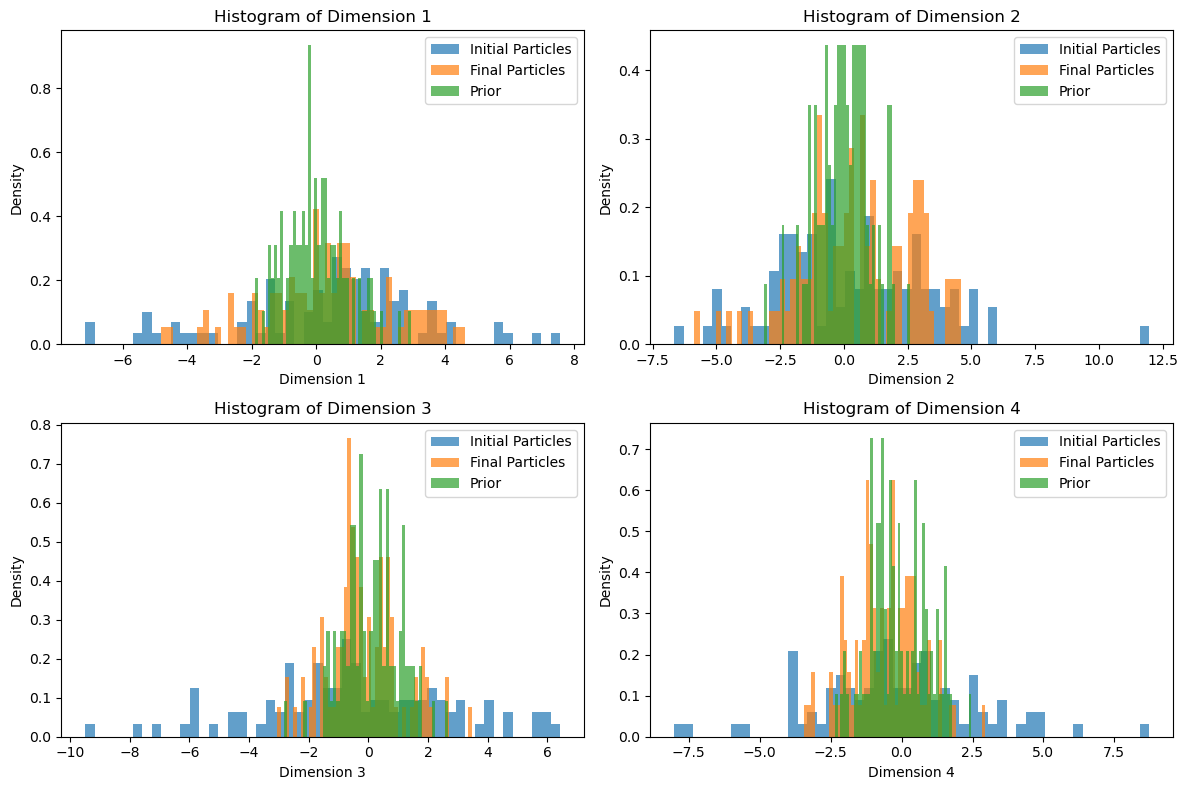

In [107]:
plt.figure(figsize=(12, 8))

#F = final_particles[i_eta, 0]
KGD_opt = KGD
prior_mass = random.normal(key, shape=(100, d))
print(F.shape)
for i in range(d):
    plt.subplot(2, 2, i + 1)
    plt.hist(X0[:, i], bins=50, density=True, alpha=0.7, label='Initial Particles')
    plt.hist(F[:, i], bins=50, density=True, alpha=0.7, label='Final Particles')
    plt.hist(prior_mass[:, i], bins=50, density=True, alpha=0.7, label='Prior')
    plt.xlabel(f'Dimension {i + 1}')
    plt.ylabel('Density')
    plt.title(f'Histogram of Dimension {i + 1}')
    plt.legend()

plt.tight_layout()
plt.show()

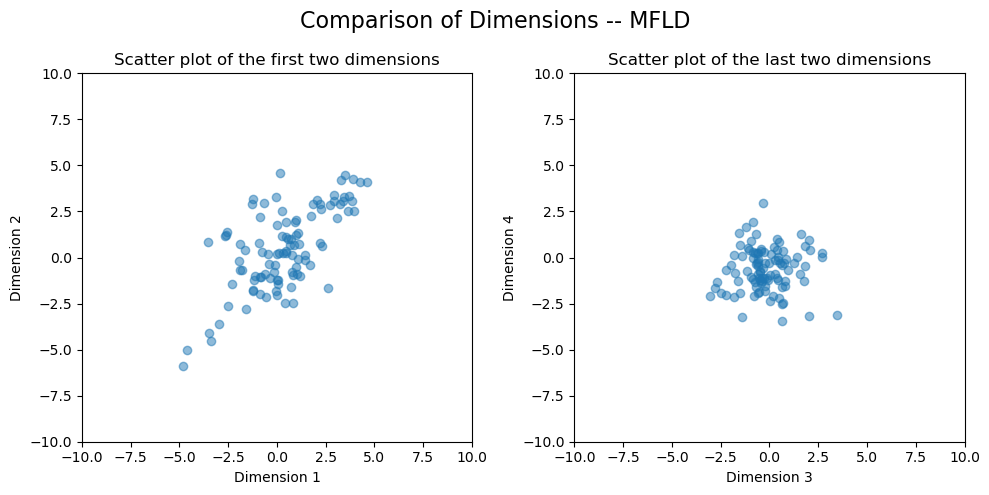

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# First scatter plot
axes[0].scatter(F[:, 0], F[:, 1], alpha=0.5)
axes[0].set_xlim(-10, 10)
axes[0].set_ylim(-10, 10)
axes[0].set_xscale('linear')
axes[0].set_yscale('linear')
axes[0].set_xlabel('Dimension 1')
axes[0].set_ylabel('Dimension 2')
axes[0].set_title('Scatter plot of the first two dimensions')

# Second scatter plot
axes[1].scatter(F[:, 2], F[:, 3], alpha=0.5)
axes[1].set_xlim(-10, 10)
axes[1].set_ylim(-10, 10)
axes[1].set_xscale('linear')
axes[1].set_yscale('linear')
axes[1].set_xlabel('Dimension 3')
axes[1].set_ylabel('Dimension 4')
axes[1].set_title('Scatter plot of the last two dimensions')
fig.suptitle("Comparison of Dimensions -- MFLD", fontsize=16)
plt.tight_layout()
plt.show()

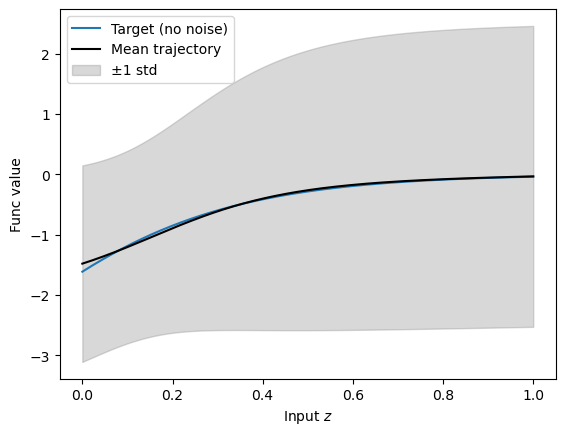

In [109]:
N = len(F)
ntestpoints = 400
Ztest = jnp.linspace(0, 1, ntestpoints).reshape(-1, 1)
target_values = target_function(Ztest)
predictions = vmap(lambda i: vmap(lambda z: forward_(F[None, i, :], z, unravel_fn))(Ztest))(jnp.arange(N))

mean = predictions.mean(axis=0)
std = predictions.std(axis=0)
plt.plot(Ztest.squeeze(), target_values, label='Target (no noise)')
plt.plot(Ztest.squeeze(), mean, color="k", label="Mean trajectory")
plt.fill_between(Ztest.squeeze(), mean - std, mean + std,
                 color="gray", alpha=0.3, label="±1 std")
# plt.heatmap(predictions, cmap="viridis", cbar=True)

# plt.plot(Ztest, prediction, label='Prediction')
plt.xlabel('Input $z$')
plt.ylabel('Func value')
# plt.title('Learned function for step size eta: {0:.3e}'.format(etas[i_eta]))
plt.legend()
plt.show()

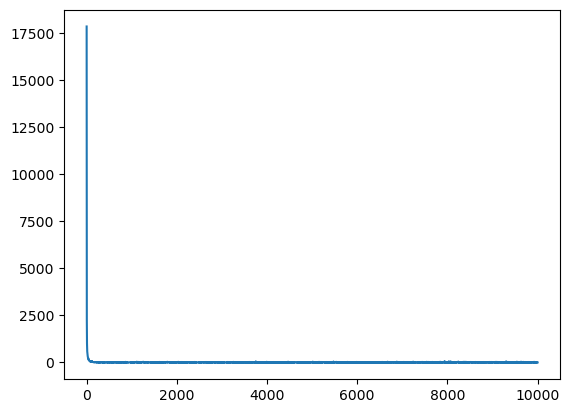

In [110]:
KGD_values = []
for it in range(T):
    KGD_values.append(kgd(k_pq, particles_opt[it]))
plt.plot(KGD_values)


In [111]:
import pickle

with open("results_heishiro.pkl", "rb") as g:
    results_heishiro = pickle.load(g)

In [120]:
results_heishiro["MFLD"]["X_fin"] = F
results_heishiro["MFLD"]["KGD_values"] = KGD_values

# Contour 

In [113]:
key = random.PRNGKey(42)
X0 = 3*random.normal(subkey, shape=(300, d))
X0 = jax.device_put(X0, device)
particles_contour = MFLD.run_particles(key, 1e-6, 100000, X0)
F_contour = particles_contour[-1]

In [114]:
F_contour = particles_contour[-1]

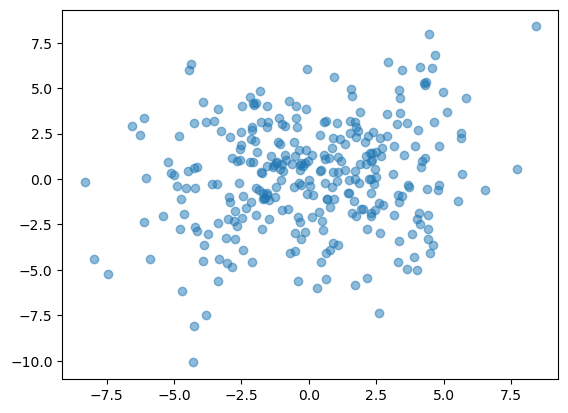

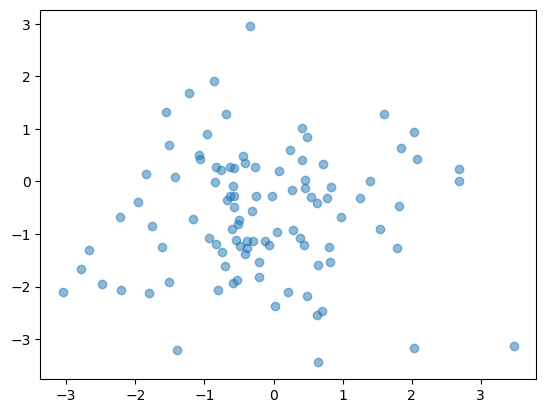

In [115]:
plt.scatter(F_contour[:, 0], F_contour[:, 1], alpha=0.5)
plt.show()
plt.scatter(F[:, 2], F[:, 3], alpha=0.5)

In [119]:
results_heishiro["MFLD contour"]["X_fin"] = F_contour

In [121]:
import pickle

with open("results_heishiro.pkl", "wb") as g:
    pickle.dump(results_heishiro, g)

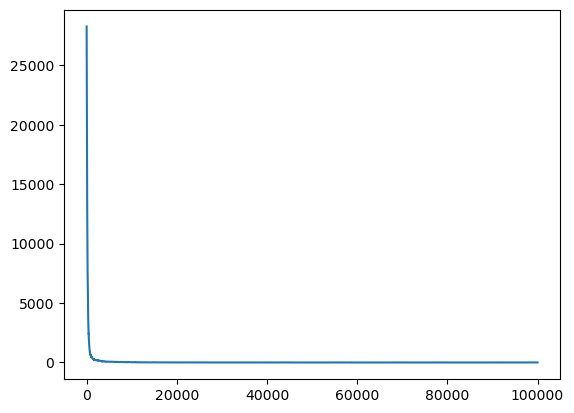

In [118]:
KGD_values = []
for it in range(100000):
    KGD_values.append(kgd(k_pq, particles_contour[it]))
plt.plot(KGD_values)